In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

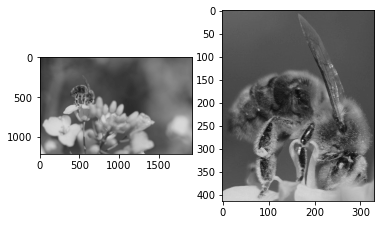

In [104]:
source_img = cv2.imread("C:\\Users\\86994\\Desktop\\beans.jpg") # 读入图片
source_img_T = cv2.imread("C:\\Users\\86994\\Desktop\\beansT.jpg") # 读入图片
img_display = source_img.copy()
source_img = cv2.cvtColor(source_img, cv2.COLOR_BGR2GRAY)
source_img_T = cv2.cvtColor(source_img_T, cv2.COLOR_BGR2GRAY)
plt.subplot(1,2,1)
plt.imshow(source_img, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(source_img_T, cmap='gray')
plt.show()

In [109]:
_t1 = time.time()
# match_method = cv2.TM_SQDIFF
match_method = cv2.TM_CCOEFF
result = cv2.matchTemplate(source_img, source_img_T, match_method)
print(time.time()-_t1)

0.22185134887695312


In [110]:
# cv2.normalize( result, result, 0, 1, cv2.NORM_MINMAX, -1 ) #可以不用这一句
# _minVal, _maxVal, minLoc, maxLoc = cv2.minMaxLoc(result, None)

_minVal, _maxVal = np.min(result), np.max(result)
_y, _x = np.where(result==_minVal) # 最大值所在的行、列，行为y
minLoc = (_x[0], _y[0])
_y, _x = np.where(result==_maxVal) # 最大值所在的行、列，行为y
maxLoc = (_x[0], _y[0])

if (match_method == cv2.TM_SQDIFF or match_method == cv2.TM_SQDIFF_NORMED):
    matchLoc = minLoc
else:
    matchLoc = maxLoc


In [111]:
# shape里面为hw
_ = cv2.rectangle(img_display, matchLoc, 
(matchLoc[0] + source_img_T.shape[1], matchLoc[1] + source_img_T.shape[0]), (0,0,255), 6, 8, 0 )


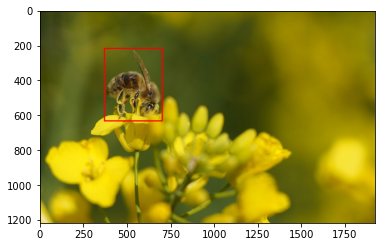

In [112]:
plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
plt.imshow(result, cmap='gray')
plt.show()